#### Description:

In [2]:
'''
    I aim to Build a Model That Predicat the salary based on:
        (city, occupation, field, years_of_experience, employment_type, education_level, gender, company_size)
'''

'\n    I aim to Build a Model That Predicat the salary based on:\n        (city, occupation, field, years_of_experience, employment_type, education_level, gender, company_size)\n'

#### Import Data and Select Features

In [3]:
# Import Packages
import pandas as pd

In [4]:
from google.colab import drive
drive.mount('/content/drive')
%ls drive/MyDrive/job_market_dataset.csv

data = pd.read_csv("drive/MyDrive/job_market_dataset.csv")
# data = pd.read_csv("./data/job_market_dataset.csv")
data.head(2)

Mounted at /content/drive
drive/MyDrive/job_market_dataset.csv


,country,city,occupation,field,years_of_experience,salary,employment_type,education_level,gender,company_size,year,month
0,Switzerland,Zurich,Operations Manager,Operations,16,359609.0,work_from_home,Master,Male,Large,2023,8
1,India,Bangalore,HR Analyst,Human Resources,12,79059.0,part_time,PhD,Male,Large,2023,5


In [5]:
# Delete Features (year, month)
cp_data = data.drop(["year", "month"], axis=1)
cp_data = cp_data.iloc[:20000] # take just 100K
cp_data.head(4)

,country,city,occupation,field,years_of_experience,salary,employment_type,education_level,gender,company_size
0,Switzerland,Zurich,Operations Manager,Operations,16,359609.0,work_from_home,Master,Male,Large
1,India,Bangalore,HR Analyst,Human Resources,12,79059.0,part_time,PhD,Male,Large
2,Sweden,Stockholm,Software Engineer,Technology,10,258077.0,freelance,Master,Male,Enterprise
3,South Korea,Seoul,Operations Manager,Operations,7,252282.0,part_time,Master,Female,Large


#### Feature Encoding

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
from sklearn.preprocessing import LabelEncoder # for Mapping / Label Encoder
from sklearn.preprocessing import OneHotEncoder # for One Hot Encoding

In [8]:
# Mapping/Label Encoding This Varaibles
company_size_map = {'Large': 3, 'Enterprise': 2, 'Medium': 1, 'Small': 0}
cp_data["company_size"] = [company_size_map[v] for v in cp_data["company_size"]]

gender_map = {'Male': 0, 'Female': 1, 'Other': 2}
cp_data["gender"] = [gender_map[v] for v in cp_data["gender"]]

education_level_map = {'PhD': 3, 'Master': 2, 'Bachelor': 1, 'High School': 0}
cp_data["education_level"] = [education_level_map[v] for v in cp_data["education_level"]]

# One-Hot-Encoding
one_hot_encoder = OneHotEncoder()
cp_data = pd.get_dummies(cp_data, columns=["field", "employment_type", "city", "country", "occupation"])
cp_data.head(3)

,years_of_experience,salary,education_level,gender,company_size,field_Business,field_Design,field_Finance,field_Human Resources,field_Marketing,field_Operations,field_Technology,employment_type_freelance,employment_type_full_time,employment_type_internship,employment_type_part_time,employment_type_work_from_home,city_Amsterdam,city_Auckland,city_Bangalore,city_Berlin,city_Cape Town,city_Dubai,city_Dublin,city_London,city_Madrid,city_Mexico City,city_Milan,city_New York,city_Paris,city_San Francisco,city_Sao Paulo,city_Seoul,city_Singapore,city_Stockholm,city_Sydney,city_Tokyo,city_Toronto,city_Zurich,country_Australia,country_Brazil,country_Canada,country_France,country_Germany,country_India,country_Ireland,country_Italy,country_Japan,country_Mexico,country_Netherlands,country_New Zealand,country_Singapore,country_South Africa,country_South Korea,country_Spain,country_Sweden,country_Switzerland,country_United Arab Emirates,country_United Kingdom,country_United States,occupation_AI Engineer,occupation_Business Analyst,occupation_Cloud Engineer,occupation_Data Analyst,occupation_Data Scientist,occupation_Financial Analyst,occupation_HR Analyst,occupation_Marketing Specialist,occupation_Operations Manager,occupation_Product Manager,occupation_Software Engineer,occupation_UX Designer
0,16,359609.0,2,0,3,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,12,79059.0,3,0,3,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
2,10,258077.0,2,0,2,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


#### Split Data

In [9]:
# Get X and y
X = cp_data.drop("salary", axis=1)
y = cp_data["salary"]

In [10]:
# Split Train Set, Test Set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.head(3)

,years_of_experience,education_level,gender,company_size,field_Business,field_Design,field_Finance,field_Human Resources,field_Marketing,field_Operations,field_Technology,employment_type_freelance,employment_type_full_time,employment_type_internship,employment_type_part_time,employment_type_work_from_home,city_Amsterdam,city_Auckland,city_Bangalore,city_Berlin,city_Cape Town,city_Dubai,city_Dublin,city_London,city_Madrid,city_Mexico City,city_Milan,city_New York,city_Paris,city_San Francisco,city_Sao Paulo,city_Seoul,city_Singapore,city_Stockholm,city_Sydney,city_Tokyo,city_Toronto,city_Zurich,country_Australia,country_Brazil,country_Canada,country_France,country_Germany,country_India,country_Ireland,country_Italy,country_Japan,country_Mexico,country_Netherlands,country_New Zealand,country_Singapore,country_South Africa,country_South Korea,country_Spain,country_Sweden,country_Switzerland,country_United Arab Emirates,country_United Kingdom,country_United States,occupation_AI Engineer,occupation_Business Analyst,occupation_Cloud Engineer,occupation_Data Analyst,occupation_Data Scientist,occupation_Financial Analyst,occupation_HR Analyst,occupation_Marketing Specialist,occupation_Operations Manager,occupation_Product Manager,occupation_Software Engineer,occupation_UX Designer
17218,4,1,0,1,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False
15188,9,3,0,1,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
11295,22,0,0,2,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False


In [10]:
# Save Test Set as CSV File
X_test.to_csv("./x_test_set.csv", index=False)
y_test.to_csv("./y_test_set.csv", index=False)

#### Model Building (Random Forest)

In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, r2_score as r_2, classification_report
from math import sqrt
import matplotlib.pyplot as plt

In [ ]:
# Build a Model
# Random Forest Hyperparameter Tuning
'''
    - n_estimators: number of trees in forset, more trees improve the model but increase cost
    - max_features: limit number of features when splitting a node --> this help control overfitting
    - max_depth: control max depth for each tree
    - max_leaf_nodes: limit number of leaf node for each tree
    - max_samples: how much smaples we give to Bootstrap Set
    - min_samples_split: specify the number of smaples required to split an internal node

    --> GridSearchCV and RandomizedSearchCV are Technics Used to Discover The bEst Parameters.
'''

param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "max_features": [10, 20, 30],
    "max_depth": [10, 20, 30, 40],
    "max_samples": [100],
    "min_samples_split": [80]
}
grid_search = GridSearchCV(RandomForestRegressor(oob_score=True), param_grid=param_grid)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)
# model = RandomForestRegressor(oob_score=True)

Best Parameters: {'max_depth': 10, 'max_features': 30, 'max_samples': 100, 'min_samples_split': 80, 'n_estimators': 300}
Best Estimator: RandomForestRegressor(max_depth=10, max_features=30, max_samples=100,
                      min_samples_split=80, n_estimators=300, oob_score=True)


In [ ]:
model = RandomForestRegressor(max_depth=10, max_features=30, max_samples=100, min_samples_split=80, n_estimators=300, oob_score=True)
model.fit(X_train, y_train)

RandomForestRegressor(oob_score=True)

In [59]:
# Calculate R2 for Tranning Set
y_pred = model.predict(X_train)
y_pred
r2_score(y_train, y_pred)

0.9793219371888517

In [60]:
# Calculate R2 for Tranning Set
y_pred = model.predict(X_test)
y_pred
r2_score(y_test, y_pred)

0.843584227348695

In [66]:
# Get Mean Absolute Error (MAE)
mae(y_pred=y_pred, y_true=y_test)
rmse(y_pred=y_pred, y_true=y_test)

33749.79094532598

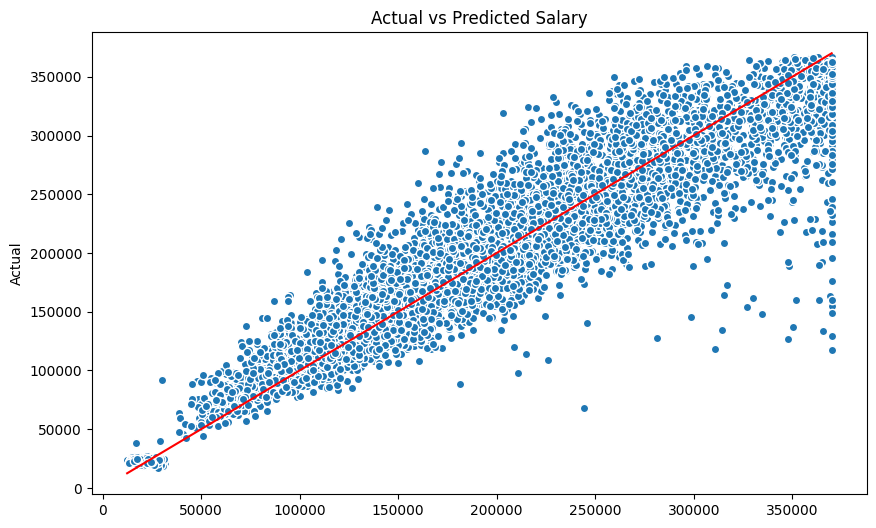

In [61]:
# The Residuals
plt.figure(figsize=(10, 6))

# Add Scatter For Visualzing The Points
plt.scatter(y_test, y_pred, edgecolors="w")
plt.ylabel("Prediction")
plt.ylabel("Actual")
plt.title('Actual vs Predicted Salary')

# Visuale The Line For The Prefect Prediction
limits = [min(y_test), max(y_test)]
plt.plot(limits, limits, color="red", linestyle="-", ) # draw line with coordinate (x1, y1) and (x2, y2)

<BarContainer object of 71 artists>

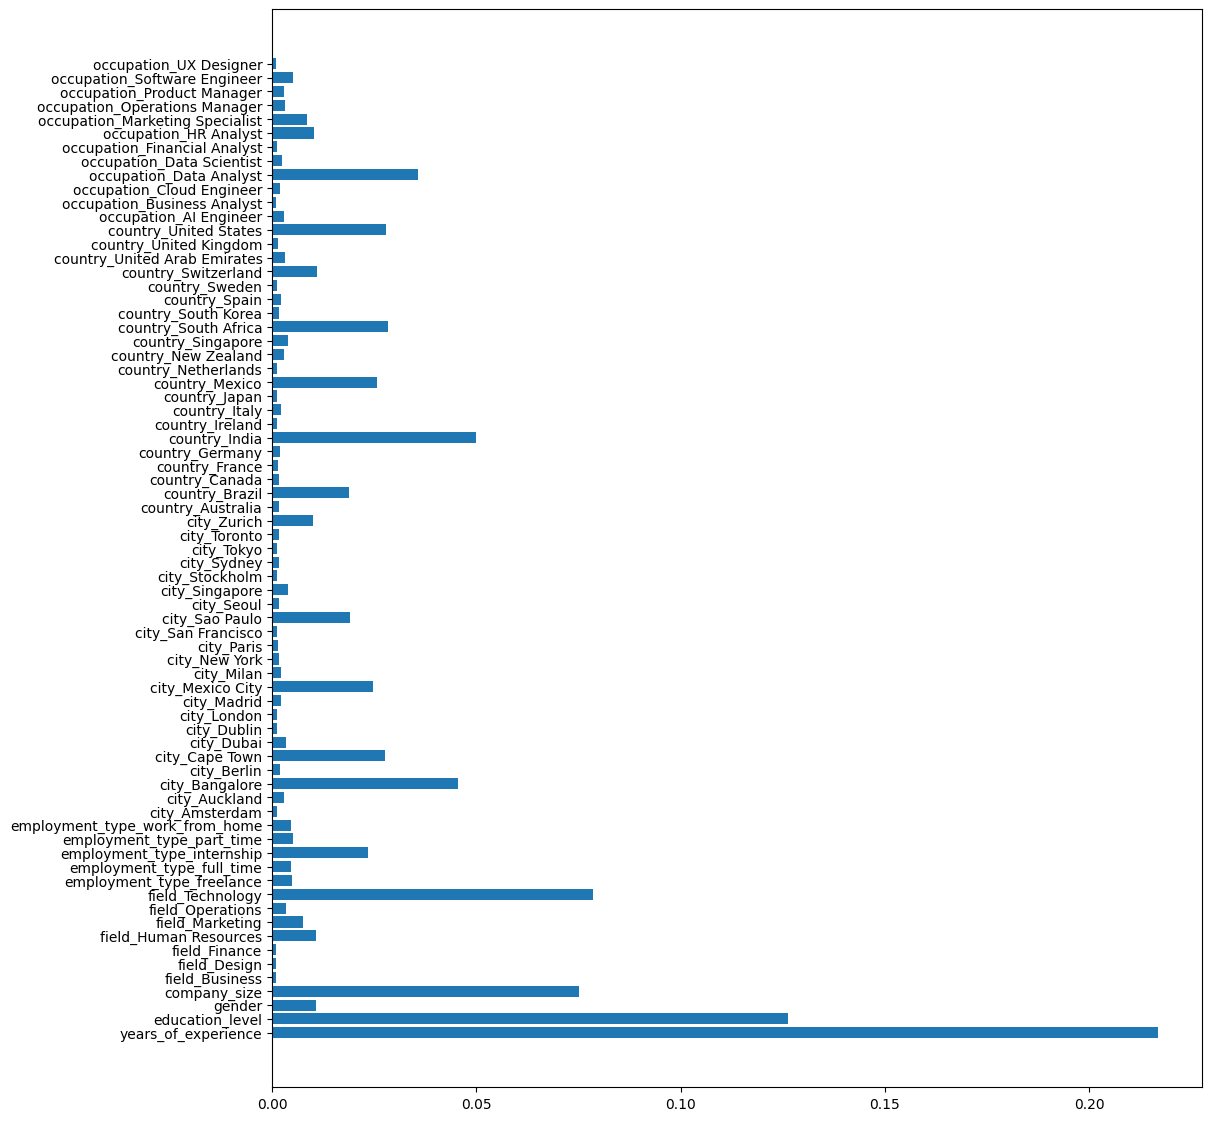

In [64]:
# Features Importance
features_names = list(model.feature_names_in_)
features_importances = list(model.feature_importances_)

# Visuale The Feature Importance
plt.figure(figsize=(12, 14))
plt.barh(features_names, features_importances)

#### Save Model As PKL file

In [14]:
import joblib

In [15]:
# Save Model
joblib.dump(model, 'my_model.pkl')
print("Model saved successfully!")

Model saved successfully!


In [17]:
# Save Model --> PKL file in Google Drive
!mv my_model.pkl drive/MyDrive/git_projects/